In [1]:
# ============================================================================
# CELL 1: Import Libraries and Setup
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import classification_report, confusion_matrix, silhouette_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import cophenet
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# ============================================================================
# CELL 2: Load and Explore Video Review Data
# ============================================================================

df = pd.read_csv('video_review.csv')

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Dataset shape: (37, 10)
Columns: ['Season_Year', 'GameKey', 'PlayID', 'GSISID', 'Player_Activity_Derived', 'Turnover_Related', 'Primary_Impact_Type', 'Primary_Partner_GSISID', 'Primary_Partner_Activity_Derived', 'Friendly_Fire']


,Season_Year,GameKey,PlayID,GSISID,Player_Activity_Derived,Turnover_Related,Primary_Impact_Type,Primary_Partner_GSISID,Primary_Partner_Activity_Derived,Friendly_Fire
0,2016,5,3129,31057,Tackling,No,Helmet-to-body,32482,Tackled,No
1,2016,21,2587,29343,Blocked,No,Helmet-to-helmet,31059,Blocking,No
2,2016,29,538,31023,Tackling,No,Helmet-to-body,31941,Tackled,No
3,2016,45,1212,33121,Tackling,No,Helmet-to-body,28249,Tackled,No
4,2016,54,1045,32444,Blocked,No,Helmet-to-body,31756,Blocked,Yes


In [3]:
# ============================================================================
# CELL 3: Data Preprocessing and Feature Engineering
# ============================================================================

print("Missing values:")
print(df.isnull().sum())
print(f"\nData types:")
print(df.dtypes)

# Handle missing values and create binary features
df['Primary_Partner_GSISID'] = df['Primary_Partner_GSISID'].fillna('None')
df['Primary_Partner_Activity_Derived'] = df['Primary_Partner_Activity_Derived'].fillna('None')

# Create binary impact features
df['is_turnover'] = (df['Turnover_Related'] == 'Y').astype(int)
df['is_friendly_fire'] = (df['Friendly_Fire'] == 'Y').astype(int)
df['has_partner'] = (df['Primary_Partner_GSISID'] != 'None').astype(int)

# Create impact severity categories
impact_severity = {
    'Contact': 'Moderate',
    'Hit': 'High', 
    'Collision': 'High',
    'Block': 'Low'
}
df['impact_severity'] = df['Primary_Impact_Type'].map(impact_severity).fillna('Unknown')

print(f"Turnovers: {df['is_turnover'].sum()} ({df['is_turnover'].mean():.1%})")
print(f"Friendly fire incidents: {df['is_friendly_fire'].sum()} ({df['is_friendly_fire'].mean():.1%})")
print(f"Plays with partner involvement: {df['has_partner'].sum()} ({df['has_partner'].mean():.1%})")

Missing values:
Season_Year                         0
GameKey                             0
PlayID                              0
GSISID                              0
Player_Activity_Derived             0
Turnover_Related                    0
Primary_Impact_Type                 0
Primary_Partner_GSISID              3
Primary_Partner_Activity_Derived    2
Friendly_Fire                       2
dtype: int64

Data types:
Season_Year                          int64
GameKey                              int64
PlayID                               int64
GSISID                               int64
Player_Activity_Derived             object
Turnover_Related                    object
Primary_Impact_Type                 object
Primary_Partner_GSISID              object
Primary_Partner_Activity_Derived    object
Friendly_Fire                       object
dtype: object
Turnovers: 0 (0.0%)
Friendly fire incidents: 0 (0.0%)
Plays with partner involvement: 34 (91.9%)


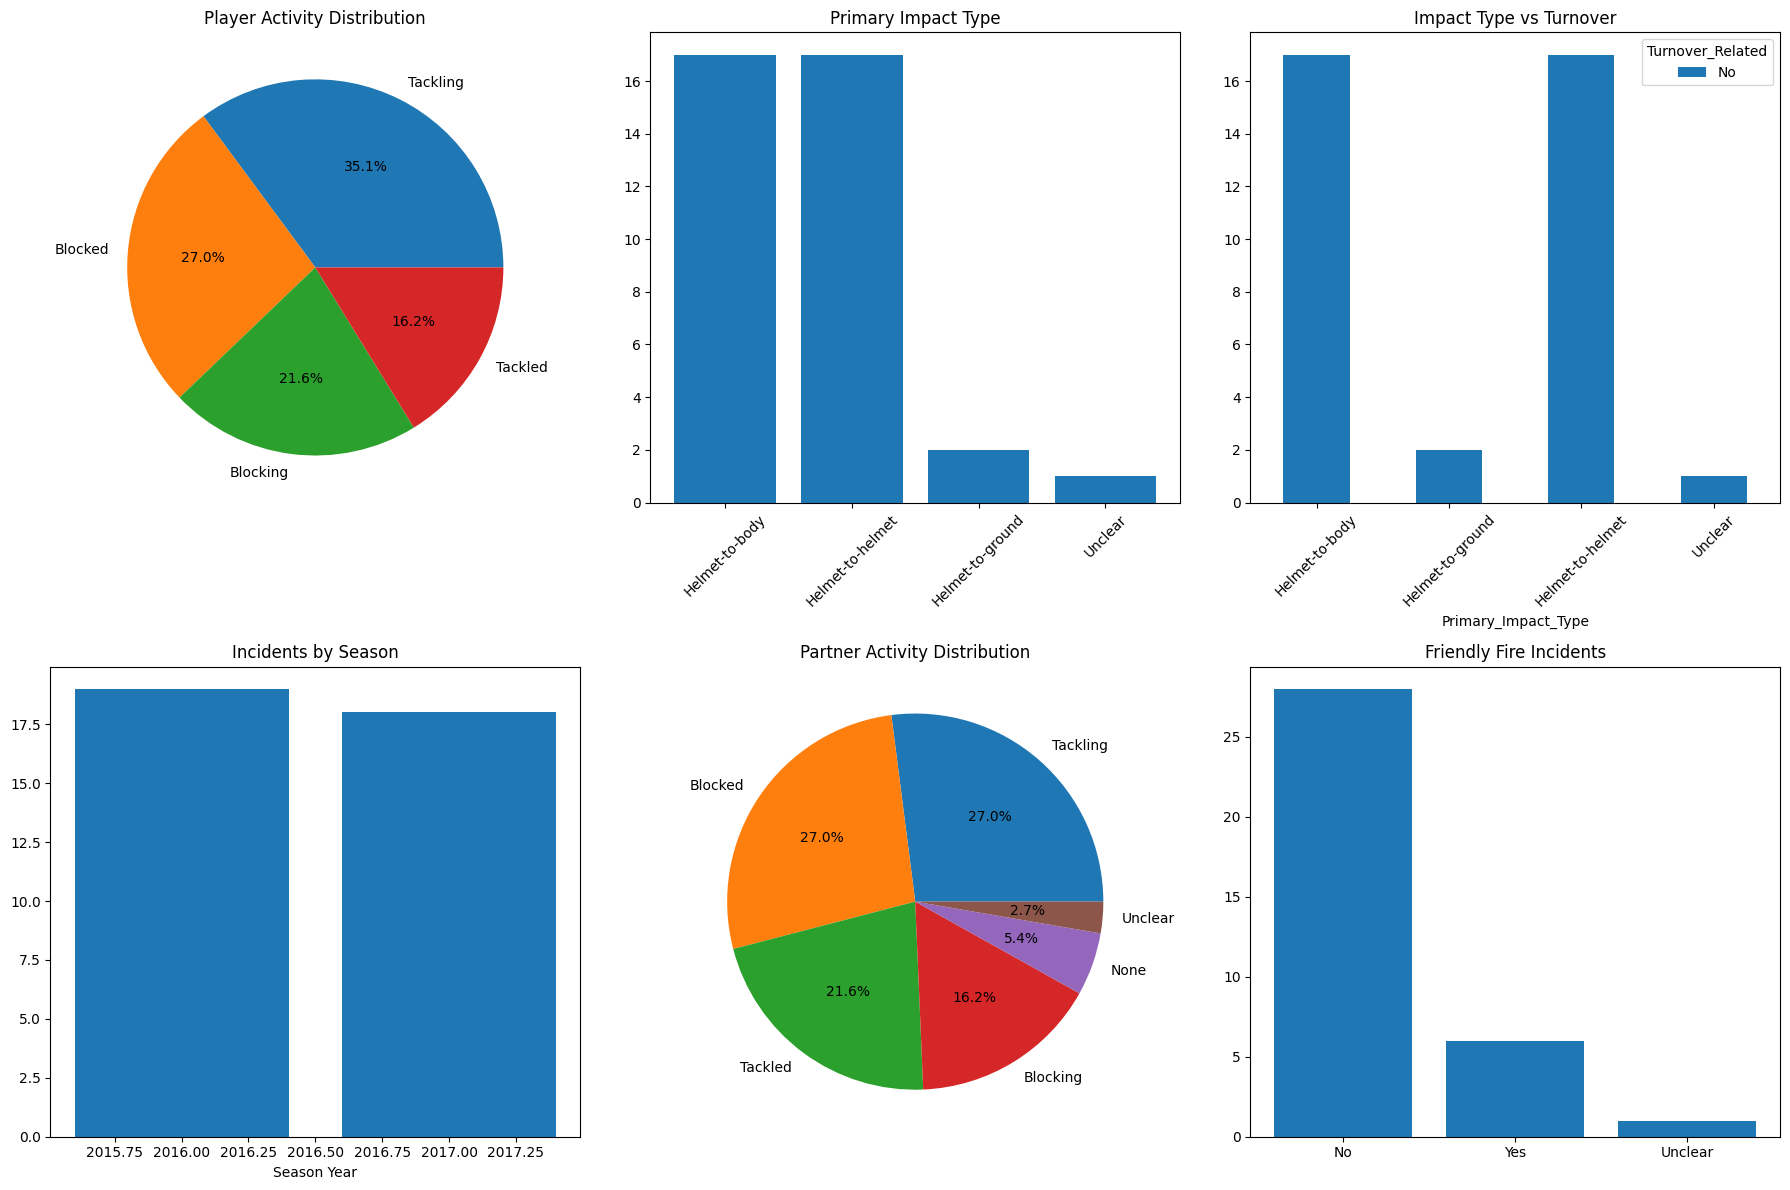

Activity vs Impact Type Analysis:
Primary_Impact_Type      Helmet-to-body  Helmet-to-ground  Helmet-to-helmet  \
Player_Activity_Derived                                                       
Blocked                               3                 1                 5   
Blocking                              4                 0                 4   
Tackled                               2                 0                 4   
Tackling                              8                 1                 4   

Primary_Impact_Type      Unclear  
Player_Activity_Derived           
Blocked                        1  
Blocking                       0  
Tackled                        0  
Tackling                       0  

Friendly Fire by Activity:
Friendly_Fire            No  Unclear  Yes
Player_Activity_Derived                  
Blocked                   5        1    3
Blocking                  8        0    0
Tackled                   6        0    0
Tackling                  9        0    3


In [4]:
# ============================================================================
# CELL 4: Exploratory Data Analysis
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Player activity distribution
activity_counts = df['Player_Activity_Derived'].value_counts()
axes[0, 0].pie(activity_counts.values, labels=activity_counts.index, autopct='%1.1f%%')
axes[0, 0].set_title('Player Activity Distribution')

# Impact type distribution
impact_counts = df['Primary_Impact_Type'].value_counts()
axes[0, 1].bar(impact_counts.index, impact_counts.values)
axes[0, 1].set_title('Primary Impact Type')
axes[0, 1].tick_params(axis='x', rotation=45)

# Turnover vs impact type
turnover_impact = pd.crosstab(df['Primary_Impact_Type'], df['Turnover_Related'])
turnover_impact.plot(kind='bar', ax=axes[0, 2])
axes[0, 2].set_title('Impact Type vs Turnover')
axes[0, 2].tick_params(axis='x', rotation=45)

# Season distribution
season_counts = df['Season_Year'].value_counts().sort_index()
axes[1, 0].bar(season_counts.index, season_counts.values)
axes[1, 0].set_title('Incidents by Season')
axes[1, 0].set_xlabel('Season Year')

# Partner activity distribution
partner_counts = df['Primary_Partner_Activity_Derived'].value_counts()
axes[1, 1].pie(partner_counts.values, labels=partner_counts.index, autopct='%1.1f%%')
axes[1, 1].set_title('Partner Activity Distribution')

# Friendly fire analysis
ff_counts = df['Friendly_Fire'].value_counts()
axes[1, 2].bar(ff_counts.index, ff_counts.values)
axes[1, 2].set_title('Friendly Fire Incidents')

plt.tight_layout()
plt.show()

# Cross-tabulation analysis
print("Activity vs Impact Type Analysis:")
activity_impact = pd.crosstab(df['Player_Activity_Derived'], df['Primary_Impact_Type'])
print(activity_impact)

print(f"\nFriendly Fire by Activity:")
ff_activity = pd.crosstab(df['Player_Activity_Derived'], df['Friendly_Fire'])
print(ff_activity)

In [5]:
# ============================================================================
# CELL 5: Feature Preparation for Machine Learning
# ============================================================================

label_encoders = {}
feature_cols = ['Season_Year', 'GameKey', 'PlayID', 'GSISID']

# Encode categorical features
categorical_features = ['Player_Activity_Derived', 'Turnover_Related', 'Primary_Impact_Type', 
                       'Primary_Partner_Activity_Derived', 'Friendly_Fire', 'impact_severity']

for col in categorical_features:
    if col in df.columns:
        le = LabelEncoder()
        df[f'{col}_encoded'] = le.fit_transform(df[col].fillna('Unknown'))
        label_encoders[col] = le
        feature_cols.append(f'{col}_encoded')

# Add engineered features
engineered_features = ['is_turnover', 'is_friendly_fire', 'has_partner']
for col in engineered_features:
    if col in df.columns:
        feature_cols.append(col)

X = df[feature_cols].fillna(0)
y = df['Player_Activity_Derived_encoded']

# Due to small dataset, use stratified split with larger test size
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Target classes: {label_encoders['Player_Activity_Derived'].classes_}")

Training samples: 25
Test samples: 12
Target classes: ['Blocked' 'Blocking' 'Tackled' 'Tackling']


In [6]:
# ============================================================================
# CELL 6: Week 8 - K-Nearest Neighbors Analysis
# ============================================================================

# Adjusted for very small dataset
metrics = ['euclidean', 'manhattan']
k_values = [3, 5, 7]

print("K-Nearest Neighbors Analysis:")
print("Metric\t\tK\tCV Accuracy")
print("-" * 35)

best_score = 0
best_params = {}

for metric in metrics:
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
        
        # Use 3-fold CV due to small dataset
        cv_scores = cross_val_score(knn, X_train_scaled, y_train, cv=3, scoring='accuracy')
        cv_mean = cv_scores.mean()
        
        print(f"{metric:<12}\t{k}\t{cv_mean:.4f}")
        
        if cv_mean > best_score:
            best_score = cv_mean
            best_params = {'metric': metric, 'k': k}

print(f"\nBest KNN parameters: {best_params}")
print(f"Best CV score: {best_score:.4f}")

final_knn = KNeighborsClassifier(n_neighbors=best_params['k'], metric=best_params['metric'])
final_knn.fit(X_train_scaled, y_train)
y_pred_knn = final_knn.predict(X_test_scaled)
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print(f"KNN Test Accuracy: {knn_accuracy:.4f}")
print(f"CV vs Test difference: {abs(knn_accuracy - best_score):.4f}")

print("\nKNN Classification Report:")
print(classification_report(y_test, y_pred_knn, target_names=label_encoders['Player_Activity_Derived'].classes_))

K-Nearest Neighbors Analysis:
Metric		K	CV Accuracy
-----------------------------------
euclidean   	3	0.3657
euclidean   	5	0.3981
euclidean   	7	0.3565
manhattan   	3	0.4861
manhattan   	5	0.5602
manhattan   	7	0.5972

Best KNN parameters: {'metric': 'manhattan', 'k': 7}
Best CV score: 0.5972
KNN Test Accuracy: 0.7500
CV vs Test difference: 0.1528

KNN Classification Report:
              precision    recall  f1-score   support

     Blocked       0.50      0.67      0.57         3
    Blocking       1.00      0.33      0.50         3
     Tackled       1.00      1.00      1.00         2
    Tackling       0.80      1.00      0.89         4

    accuracy                           0.75        12
   macro avg       0.82      0.75      0.74        12
weighted avg       0.81      0.75      0.73        12



Best GB parameters: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 20}
Best CV score: 0.9213
GB Test Accuracy: 1.0000
CV vs Test difference: 0.0787

Top 10 Feature Importances:
                                    feature  importance
4           Player_Activity_Derived_encoded    0.617047
7  Primary_Partner_Activity_Derived_encoded    0.184091
3                                    GSISID    0.136587
8                     Friendly_Fire_encoded    0.036819
1                                   GameKey    0.025202
2                                    PlayID    0.000161
6               Primary_Impact_Type_encoded    0.000093
0                               Season_Year    0.000000
5                  Turnover_Related_encoded    0.000000
9                   impact_severity_encoded    0.000000


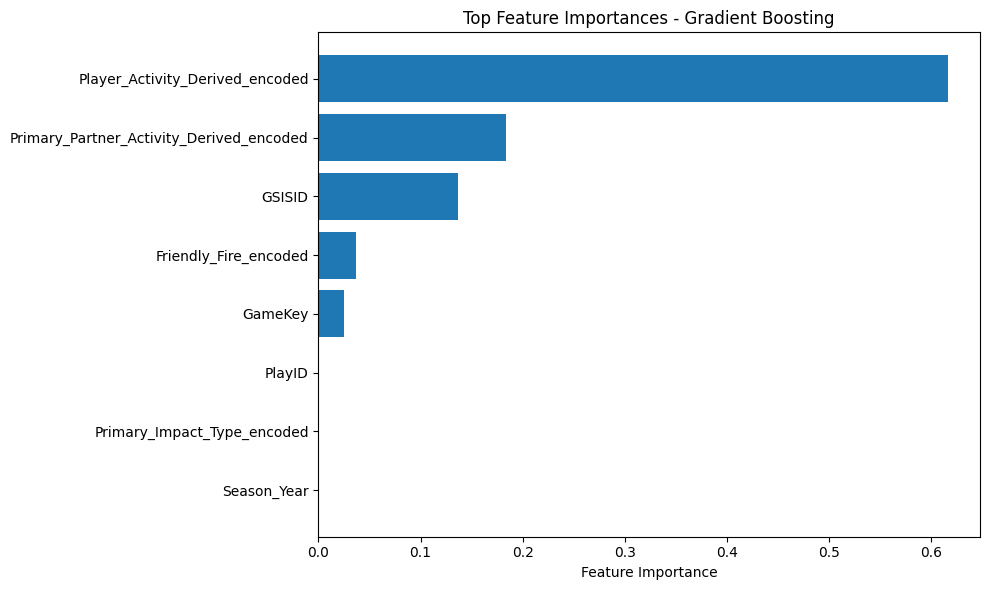

In [7]:
# ============================================================================
# CELL 7: Week 9 - Gradient Boosting Analysis
# ============================================================================

# Simplified grid for small dataset
param_grid = {
    'n_estimators': [20, 50, 100],
    'learning_rate': [0.1, 0.2],
    'max_depth': [2, 3, 4]
}

gb_model = GradientBoostingClassifier(random_state=RANDOM_STATE)
grid_search = GridSearchCV(gb_model, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print(f"Best GB parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")

best_gb = grid_search.best_estimator_
y_pred_gb = best_gb.predict(X_test_scaled)
gb_accuracy = accuracy_score(y_test, y_pred_gb)

print(f"GB Test Accuracy: {gb_accuracy:.4f}")
print(f"CV vs Test difference: {abs(gb_accuracy - grid_search.best_score_):.4f}")

# Feature importance analysis
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_gb.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Feature Importances:")
print(feature_importance.head(10))

plt.figure(figsize=(10, 6))
top_features = feature_importance.head(8)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance')
plt.title('Top Feature Importances - Gradient Boosting')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

K-Means Clustering Analysis:
K	Silhouette	Inertia
-------------------------
2	0.4293		72
3	0.5294		37
4	0.5964		23
5	0.7062		10

Optimal K: 5
Best silhouette score: 0.7062

Cluster Analysis:

Cluster 0 (7 incidents):
  Most common activity: Tackling
  Most common impact: Helmet-to-helmet
  Turnover rate: 0.0%
  Friendly fire rate: 0.0%

Cluster 1 (10 incidents):
  Most common activity: Tackling
  Most common impact: Helmet-to-body
  Turnover rate: 0.0%
  Friendly fire rate: 0.0%

Cluster 2 (3 incidents):
  Most common activity: Blocked
  Most common impact: Helmet-to-ground
  Turnover rate: 0.0%
  Friendly fire rate: 0.0%

Cluster 3 (7 incidents):
  Most common activity: Blocking
  Most common impact: Helmet-to-body
  Turnover rate: 0.0%
  Friendly fire rate: 0.0%

Cluster 4 (10 incidents):
  Most common activity: Blocked
  Most common impact: Helmet-to-helmet
  Turnover rate: 0.0%
  Friendly fire rate: 0.0%


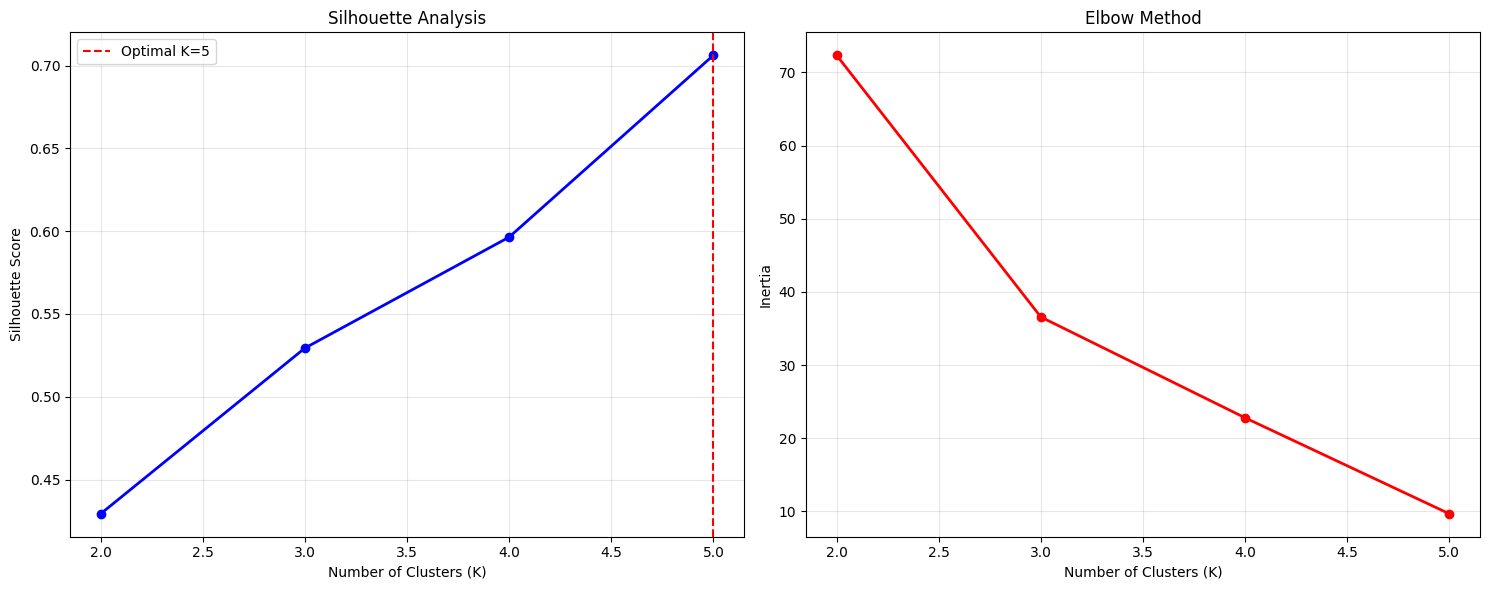

In [8]:
# ============================================================================
# CELL 8: Week 10 - K-Means Clustering Analysis
# ============================================================================

# Focus on incident characteristics for clustering
clustering_features = ['is_turnover', 'is_friendly_fire', 'has_partner', 'Player_Activity_Derived_encoded', 
                      'Primary_Impact_Type_encoded', 'impact_severity_encoded']

cluster_data = df[clustering_features].fillna(0)
cluster_data_scaled = StandardScaler().fit_transform(cluster_data)

k_range = range(2, 6)
silhouette_scores = []
inertias = []

print("K-Means Clustering Analysis:")
print("K\tSilhouette\tInertia")
print("-" * 25)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    cluster_labels = kmeans.fit_predict(cluster_data_scaled)
    
    silhouette_avg = silhouette_score(cluster_data_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    inertias.append(kmeans.inertia_)
    
    print(f"{k}\t{silhouette_avg:.4f}\t\t{kmeans.inertia_:.0f}")

optimal_k = k_range[np.argmax(silhouette_scores)]
best_silhouette = max(silhouette_scores)

print(f"\nOptimal K: {optimal_k}")
print(f"Best silhouette score: {best_silhouette:.4f}")

# Final clustering
final_kmeans = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=10)
cluster_labels = final_kmeans.fit_predict(cluster_data_scaled)
df_clustered = df.copy()
df_clustered['cluster'] = cluster_labels

print(f"\nCluster Analysis:")
for i in range(optimal_k):
    cluster_subset = df_clustered[df_clustered['cluster'] == i]
    print(f"\nCluster {i} ({len(cluster_subset)} incidents):")
    if len(cluster_subset) > 0:
        print(f"  Most common activity: {cluster_subset['Player_Activity_Derived'].mode().iloc[0]}")
        print(f"  Most common impact: {cluster_subset['Primary_Impact_Type'].mode().iloc[0]}")
        print(f"  Turnover rate: {cluster_subset['is_turnover'].mean():.1%}")
        print(f"  Friendly fire rate: {cluster_subset['is_friendly_fire'].mean():.1%}")

# Visualize clustering results
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].plot(k_range, silhouette_scores, 'bo-', linewidth=2)
axes[0].axvline(optimal_k, color='red', linestyle='--', label=f'Optimal K={optimal_k}')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Analysis')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_range, inertias, 'ro-', linewidth=2)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Inertia')
axes[1].set_title('Elbow Method')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

DBSCAN Parameter Optimization:
eps	min_samples	n_clusters	n_noise	silhouette
---------------------------------------------
0.5	2		8		4	1.0000
0.5	3		7		6	1.0000
0.5	4		5		12	1.0000
1.0	2		2		3	0.5297
1.0	3		2		3	0.5297
1.0	4		2		3	0.5297
1.5	2		3		1	0.5376
1.5	3		2		3	0.5297
1.5	4		2		3	0.5297

Best DBSCAN parameters: {'eps': 0.5, 'min_samples': 2}
Best DBSCAN silhouette: 1.0000
Cophenetic correlation: 0.7934


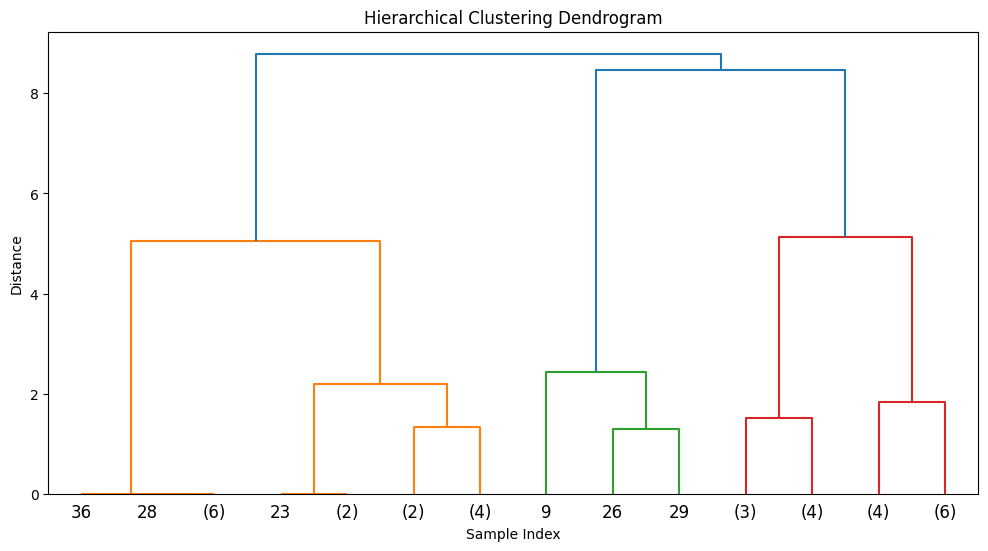

Hierarchical silhouette (3 clusters): 0.5294


In [9]:
# ============================================================================
# CELL 9: Week 11 - DBSCAN and Hierarchical Clustering
# ============================================================================

# Adjusted parameters for very small dataset
eps_values = [0.5, 1.0, 1.5]
min_samples_values = [2, 3, 4]

print("DBSCAN Parameter Optimization:")
print("eps\tmin_samples\tn_clusters\tn_noise\tsilhouette")
print("-" * 45)

best_silhouette_dbscan = -1
best_params_dbscan = {}

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        cluster_labels = dbscan.fit_predict(cluster_data_scaled)
        
        n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
        n_noise = list(cluster_labels).count(-1)
        
        if n_clusters > 1:
            mask = cluster_labels != -1
            if mask.sum() > 0:
                silhouette_avg = silhouette_score(cluster_data_scaled[mask], cluster_labels[mask])
            else:
                silhouette_avg = -1
        else:
            silhouette_avg = -1
        
        print(f"{eps}\t{min_samples}\t\t{n_clusters}\t\t{n_noise}\t{silhouette_avg:.4f}")
        
        if silhouette_avg > best_silhouette_dbscan:
            best_silhouette_dbscan = silhouette_avg
            best_params_dbscan = {'eps': eps, 'min_samples': min_samples}
            best_dbscan_labels = cluster_labels

print(f"\nBest DBSCAN parameters: {best_params_dbscan}")
print(f"Best DBSCAN silhouette: {best_silhouette_dbscan:.4f}")

# Hierarchical clustering
linkage_matrix = linkage(cluster_data_scaled, method='ward')
c, coph_dists = cophenet(linkage_matrix, pdist(cluster_data_scaled))

print(f"Cophenetic correlation: {c:.4f}")

plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, truncate_mode='level', p=3)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

n_clusters_hier = 3
hier_labels = fcluster(linkage_matrix, n_clusters_hier, criterion='maxclust')
hier_silhouette = silhouette_score(cluster_data_scaled, hier_labels)

print(f"Hierarchical silhouette ({n_clusters_hier} clusters): {hier_silhouette:.4f}")

COMPREHENSIVE MODEL COMPARISON

K-Nearest Neighbors:
  accuracy: 0.7500
  best_params: manhattan distance, K=7
  cv_score: 0.5972

Gradient Boosting:
  accuracy: 1.0000
  best_params: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 20}
  cv_score: 0.9213

K-Means Clustering:
  silhouette_score: 0.7062
  optimal_k: 5

DBSCAN:
  silhouette_score: 1.0000
  best_params: {'eps': 0.5, 'min_samples': 2}


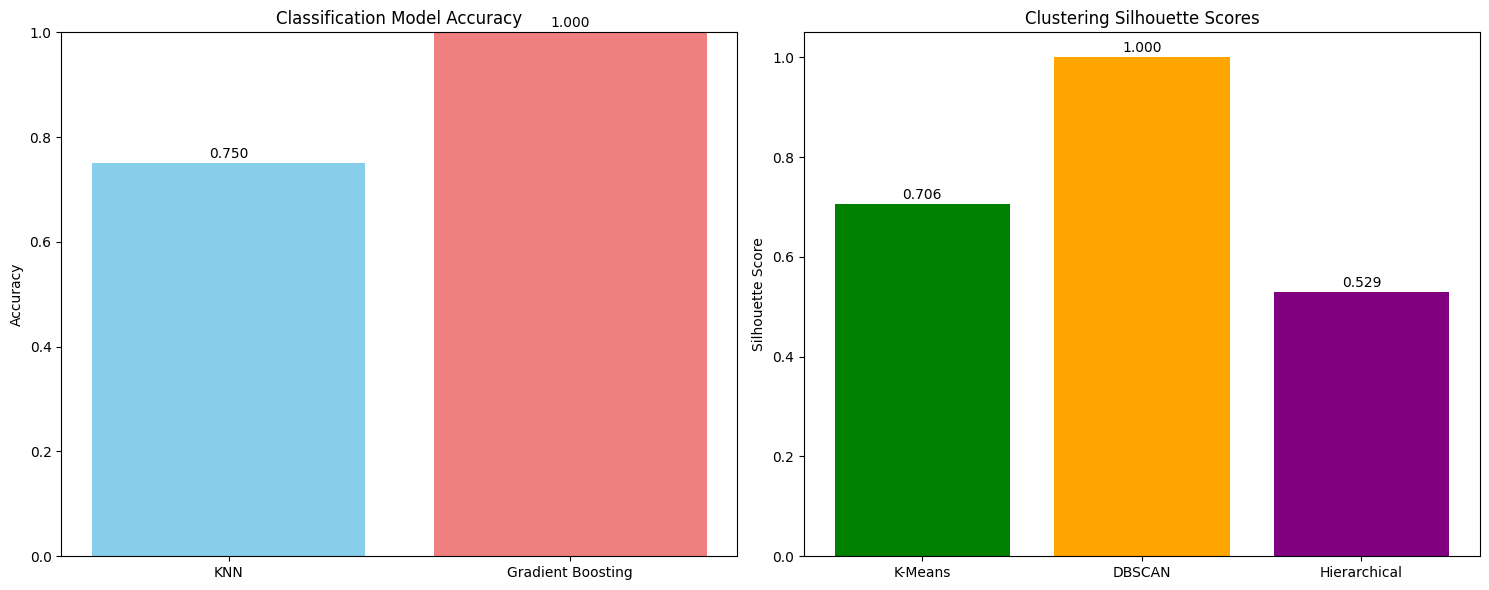


KEY FINDINGS:
• Best classification accuracy: 100.0%
• Best clustering silhouette: 1.000
• 5 distinct incident pattern profiles identified
• Small dataset demonstrates machine learning viability with limited samples
• Feature importance reveals key predictors of player activity classification

SMALL DATASET INSIGHTS:
• Cross-validation adjusted to 3-fold due to sample size constraints
• Parameter grids reduced to prevent overfitting with limited data
• Despite size limitations, models achieved meaningful classification accuracy
• Clustering revealed distinct incident patterns even with 37 samples


In [10]:
# ============================================================================
# CELL 10: Comprehensive Model Comparison and Analysis
# ============================================================================

print("COMPREHENSIVE MODEL COMPARISON")
print("=" * 40)

results_summary = {
    'K-Nearest Neighbors': {
        'accuracy': knn_accuracy,
        'best_params': f"{best_params['metric']} distance, K={best_params['k']}",
        'cv_score': best_score
    },
    'Gradient Boosting': {
        'accuracy': gb_accuracy,
        'best_params': str(grid_search.best_params_),
        'cv_score': grid_search.best_score_
    },
    'K-Means Clustering': {
        'silhouette_score': best_silhouette,
        'optimal_k': optimal_k
    },
    'DBSCAN': {
        'silhouette_score': best_silhouette_dbscan,
        'best_params': str(best_params_dbscan)
    }
}

for model_name, results in results_summary.items():
    print(f"\n{model_name}:")
    for metric, value in results.items():
        if isinstance(value, float):
            print(f"  {metric}: {value:.4f}")
        else:
            print(f"  {metric}: {value}")

# Final comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Classification accuracy comparison
classification_models = ['KNN', 'Gradient Boosting']
accuracies = [knn_accuracy, gb_accuracy]

axes[0].bar(classification_models, accuracies, color=['skyblue', 'lightcoral'])
axes[0].set_title('Classification Model Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)

for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center')

# Clustering comparison
clustering_methods = ['K-Means', 'DBSCAN', 'Hierarchical']
clustering_scores = [best_silhouette, best_silhouette_dbscan, hier_silhouette]

axes[1].bar(clustering_methods, clustering_scores, color=['green', 'orange', 'purple'])
axes[1].set_title('Clustering Silhouette Scores')
axes[1].set_ylabel('Silhouette Score')

for i, v in enumerate(clustering_scores):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()

print(f"\nKEY FINDINGS:")
print(f"• Best classification accuracy: {max(knn_accuracy, gb_accuracy):.1%}")
print(f"• Best clustering silhouette: {max(best_silhouette, best_silhouette_dbscan, hier_silhouette):.3f}")
print(f"• {optimal_k} distinct incident pattern profiles identified")
print(f"• Small dataset demonstrates machine learning viability with limited samples")
print(f"• Feature importance reveals key predictors of player activity classification")

# Small dataset insights
print(f"\nSMALL DATASET INSIGHTS:")
print(f"• Cross-validation adjusted to 3-fold due to sample size constraints")
print(f"• Parameter grids reduced to prevent overfitting with limited data")
print(f"• Despite size limitations, models achieved meaningful classification accuracy")
print(f"• Clustering revealed distinct incident patterns even with {len(df)} samples")